# **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')

# **Loading the data from HF**

In [ ]:
emotion_data = load_dataset('dair-ai/emotion')
emotion_data

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
train_text = emotion_data['train']['text']
train_label = emotion_data['train']['label']

test_text = emotion_data['test']['text']
test_label = emotion_data['test']['label']

In [ ]:
label_names = emotion_data['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
train_df = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
     }
)

In [ ]:
train_df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
test_df = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

test_df.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [ ]:
train_df.isnull().sum()

,0
text,0
label,0


In [ ]:
test_df.isnull().sum()

,0
text,0
label,0


# **Exploratory Data Analysis**

In [ ]:
train_df['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

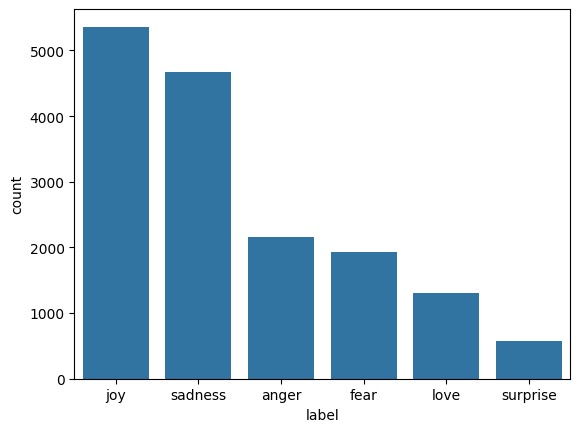

In [ ]:
sns.countplot(x = 'label', data = train_df, order = train_df['label'].value_counts().index)

The data is imbalanced with more "joy" labels

# **Data Preprocessing**

In [ ]:
train_df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

# tokenizing the text
tokenizer = Tokenizer(num_words = max_words, oov_token = '')

tokenizer.fit_on_texts(train_df['text'])

In [ ]:
# words to numbers (unique -> higher number)
train_seq = tokenizer.texts_to_sequences(train_df['text'])
test_seq = tokenizer.texts_to_sequences(test_df['text'])


In [ ]:
# to have same input size at all times we use padded seq i.e, we add 0s at the end to cover the input size

padded_train_seq = pad_sequences(train_seq, maxlen= 50, padding = 'post', truncating = 'post')
padded_test_seq = pad_sequences(test_seq, maxlen= 50, padding = 'post', truncating = 'post')

In [ ]:
train_labels = np.array(train_label)
test_labels = np.array(test_label)

In [ ]:
num_classes = len(np.unique(train_labels))
num_classes

6

In [ ]:
print(f"Vocal size : {len(tokenizer.word_index)}")
print(f"Max Sentence length: {padded_train_seq.shape[1]}")

Vocal size : 15213
Max Sentence length: 50


In [ ]:
from sklearn.utils import class_weight

# weight = total_samples / (num_classes * samples_in_that_class)

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weights

array([0.57151022, 0.49732687, 2.04498978, 1.23513973, 1.37669936,
       4.66200466])

In [ ]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

# **Training Models**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, Bidirectional, GRU


Simple RNN

In [ ]:
rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units = 128, return_sequences = True),
    Dropout(0.5),
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

rnn_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'] )

rnn_model.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.1550 - loss: 1.9506 - val_accuracy: 0.1800 - val_loss: 1.7899
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1637 - loss: 1.8074 - val_accuracy: 0.1660 - val_loss: 1.7640
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.1599 - loss: 1.7862 - val_accuracy: 0.1500 - val_loss: 1.7722
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.1520 - loss: 1.7707 - val_accuracy: 0.0815 - val_loss: 1.8236
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.1471 - loss: 1.7640 - val_accuracy: 0.0785 - val_loss: 1.8326


In [ ]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_seq, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1660 - loss: 1.7640
RNN Loss: 1.764022946357727
RNN Accuracy: 0.16599999368190765


LSTM

In [ ]:
lstm_model = Sequential([
    Embedding( input_dim = 10000, output_dim = 128, input_length = 50),
    LSTM(units = 128, return_sequences = True),
    Dropout(0.5),
    LSTM(units = 64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

lstm_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'] )
lstm_model.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_seq, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - accuracy: 0.1616 - loss: 1.7952 - val_accuracy: 0.1385 - val_loss: 1.7938
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 160ms/step - accuracy: 0.1381 - loss: 1.7938 - val_accuracy: 0.0985 - val_loss: 1.7813
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 140ms/step - accuracy: 0.1589 - loss: 1.7922 - val_accuracy: 0.1940 - val_loss: 1.7355
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 133ms/step - accuracy: 0.1752 - loss: 1.7291 - val_accuracy: 0.2225 - val_loss: 1.6630
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 161ms/step - accuracy: 0.3246 - loss: 1.4784 - val_accuracy: 0.4155 - val_loss: 1.3774
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 92s 180ms/step - accuracy: 0.5033 - loss: 1.1623 - val_accuracy: 0.5245 - val_loss: 1.2061
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 131ms/step - accuracy: 0.7043 - loss: 0.8089 - val_accuracy: 0.7735 - val_loss: 0.6573
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.8430 - loss: 

GRU

In [ ]:
gru_model = Sequential([
    Embedding( input_dim = 10000, output_dim = 128, input_length = 50),
    GRU(units = 128, return_sequences = True),
    Dropout(0.5),
    GRU(units = 64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

gru_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'] )
gru_model.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_seq, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 129ms/step - accuracy: 0.1432 - loss: 1.7956 - val_accuracy: 0.0335 - val_loss: 1.7971
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 168ms/step - accuracy: 0.1506 - loss: 1.7938 - val_accuracy: 0.0325 - val_loss: 1.7999
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 126s 137ms/step - accuracy: 0.1387 - loss: 1.7937 - val_accuracy: 0.0800 - val_loss: 1.8227
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0335 - loss: 1.7971
GRU Loss: 1.797050952911377
GRU Accuracy: 0.03350000083446503


In [ ]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_loss, lstm_loss, gru_loss],
    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Accuracy', ascending = False)

result_df

,Model,Loss,Accuracy
1,LSTM,0.442534,0.8830
0,RNN,1.764023,0.1660
2,GRU,1.797051,0.0335


Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding( input_dim = 10000, output_dim = 128, input_length = 50),
    Bidirectional(GRU(units = 128, return_sequences = True) ),
    Dropout(0.5),
    Bidirectional(GRU(units = 64)),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

In [ ]:
BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 315ms/step - accuracy: 0.4970 - loss: 1.1712 - val_accuracy: 0.8805 - val_loss: 0.3478
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 206s 322ms/step - accuracy: 0.9161 - loss: 0.2484 - val_accuracy: 0.9060 - val_loss: 0.2676
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - accuracy: 0.9436 - loss: 0.1531 - val_accuracy: 0.9125 - val_loss: 0.2591
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 120s 239ms/step - accuracy: 0.9603 - loss: 0.1077 - val_accuracy: 0.9135 - val_loss: 0.2777
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 231ms/step - accuracy: 0.9688 - loss: 0.0880 - val_accuracy: 0.9135 - val_loss: 0.2791
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 225ms/step - accuracy: 0.9721 - loss: 0.0733 - val_accuracy: 0.9125 - val_loss: 0.2934


In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_seq, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9125 - loss: 0.2591
BiGRU Loss: 0.2591087222099304
BiGRU Accuracy: 0.9125000238418579


# **Evaluation**

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step


<Axes: >

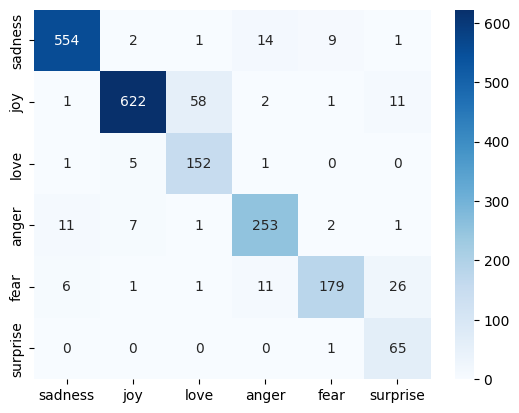

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_preds = np.argmax(BiGRU.predict(padded_test_seq),axis=1)

sns.heatmap(confusion_matrix(test_labels, BiGRU_preds),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

# **Final Predictions**

In [ ]:
sample_texts = [
    "I cant believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless now",
    "I was so furious that they cancelled the trip at the last moment.",
    "I feel terrified while walking down the dark streets alone at night.",
    "I was shocked and completely suprized by the unexpected gifts!."
]

In [ ]:
sample_seq = tokenizer.texts_to_sequences(sample_texts)
sample_padded_seq = pad_sequences(sample_seq, maxlen= 50, padding = 'post', truncating = 'post')

In [ ]:
sample_preds = np.argmax(BiGRU.predict(sample_padded_seq),axis=1)

for i in range(len(sample_texts)):
    print(f'Text: {sample_texts[i]}')
    print(f'Predicted Label: {label_names[sample_preds[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Text: I cant believe how happy I am right now, this is amazing!
Predicted Label: surprise
Text: I feel so alone and hopeless now
Predicted Label: sadness
Text: I was so furious that they cancelled the trip at the last moment.
Predicted Label: anger
Text: I feel terrified while walking down the dark streets alone at night.
Predicted Label: fear
Text: I was shocked and completely suprized by the unexpected gifts!.
Predicted Label: surprise


# **Save and Export the Model**

In [ ]:
import os
import pickle

model_directory = 'artifacts'
os.makedirs(model_directory, exist_ok=True)

In [ ]:
# save model

BiGRU.save(os.path.join(model_directory, 'model.keras'))

In [ ]:
# Save the tokenizer
tokenizer_path = os.path.join(model_directory, 'tokenizer.pkl')
with open(tokenizer_path, 'wb') as file:
    pickle.dump(tokenizer, file)